In [20]:
using HDF5
using CairoMakie
using Statistics

In [ ]:
file1 = h5open("../simplified_linear_dynamics/simplified_linear_dynamics_theory_experiment_alpha3.0.h5", "r")
file2 = h5open("../simplified_linear_dynamics/simplified_linear_dynamics_theory_experiment_tau4.0.h5", "r")

generalization_error_theory1 = read(file1, "generalization_error_theory")
taus1 = read(file1, "taus")
max_t1 = read(file1, "tmax") + 1
n_trials1 = read(file1, "n_trials")
generalization_error_experiment1 = read(file1, "generalization_error_experiment")

generalization_error_theory2 = read(file2, "generalization_error_theory")
generalization_error_experiment2 = read(file2, "generalization_error_experiment");


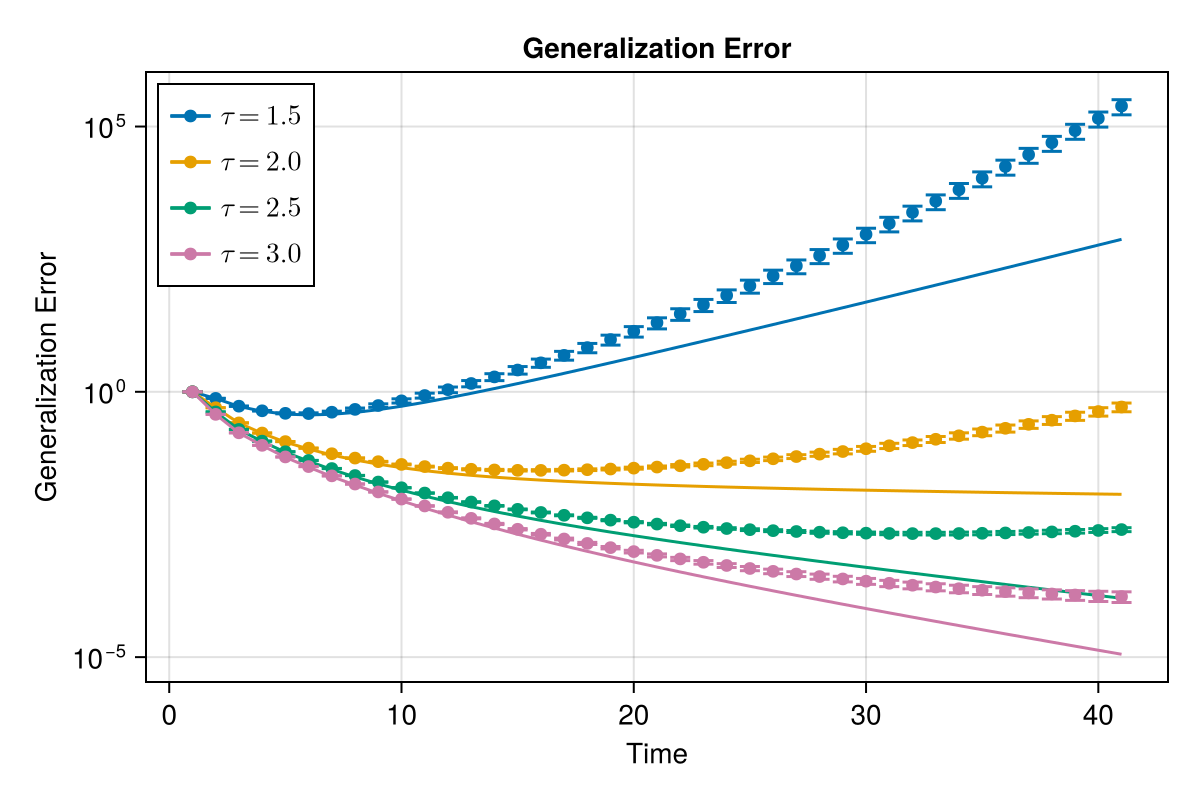

CairoMakie.Screen{IMAGE}


In [22]:
fig = Figure(size=(600, 400))
ax = Axis(fig[1, 1], 
    title="Generalization Error", xlabel="Time", ylabel="Generalization Error",
    yscale = log10)  



for i in 1:length(taus1) 
    # theory
    lines!(ax, 1:max_t1, generalization_error_theory1[i, :], label=L"\tau=%$(taus1[i])")
    # experiment
    experiment_means = vec(mean(generalization_error_experiment1[i, :, :], dims=1))
    experiment_se = vec(std(generalization_error_experiment1[i, :, :], dims=1) ./ sqrt(n_trials1))
    scatter!(ax, 1:max_t1, experiment_means, label=L"\tau=%$(taus1[i])")
    errorbars!(ax, 1:max_t1, experiment_means, experiment_se, label=L"\tau=%$(taus1[i])", whiskerwidth=10.0)
end

axislegend(ax, position=:lt, merge=true)
display(fig)